In [1]:
ethiopia.head()


NameError: name 'ethiopia' is not defined

In [2]:
import pandas as pd

In [3]:
ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/kenya_clean.csv'

In [4]:
import os
os.listdir("../data")

['ethiopia.csv',
 'ethiopia_clean.csv',
 'kenya.csv',
 'nigeria.csv',
 'sudan.csv',
 'tanzania.csv']

In [5]:
ethiopia["country"] = "Ethiopia"
kenya["country"] = "Kenya"
nigeria["country"] = "Nigeria"
sudan["country"] = "Sudan"
tanzania["country"] = "Tanzania"

NameError: name 'kenya' is not defined

In [6]:
import pandas as pd

ethiopia = pd.read_csv("../data/ethiopia_clean.csv")
kenya = pd.read_csv("../data/kenya_clean.csv")
nigeria = pd.read_csv("../data/nigeria_clean.csv")
sudan = pd.read_csv("../data/sudan_clean.csv")
tanzania = pd.read_csv("../data/tanzania_clean.csv")

In [7]:
ethiopia["country"] = "Ethiopia"
kenya["country"] = "Kenya"
nigeria["country"] = "Nigeria"
sudan["country"] = "Sudan"
tanzania["country"] = "Tanzania"

In [8]:
df_all = pd.concat([ethiopia, kenya, nigeria, sudan, tanzania])

In [9]:
df_all["country"].value_counts()

country
Ethiopia    4108
Kenya       4108
Nigeria     4108
Sudan       4108
Tanzania    4108
Name: count, dtype: int64

In [10]:
df_all["month"] = df_all["DOY"] // 30  # simple monthly grouping

In [11]:
temp_by_country = df_all.groupby(["country", "month"])["T2M"].mean().reset_index()

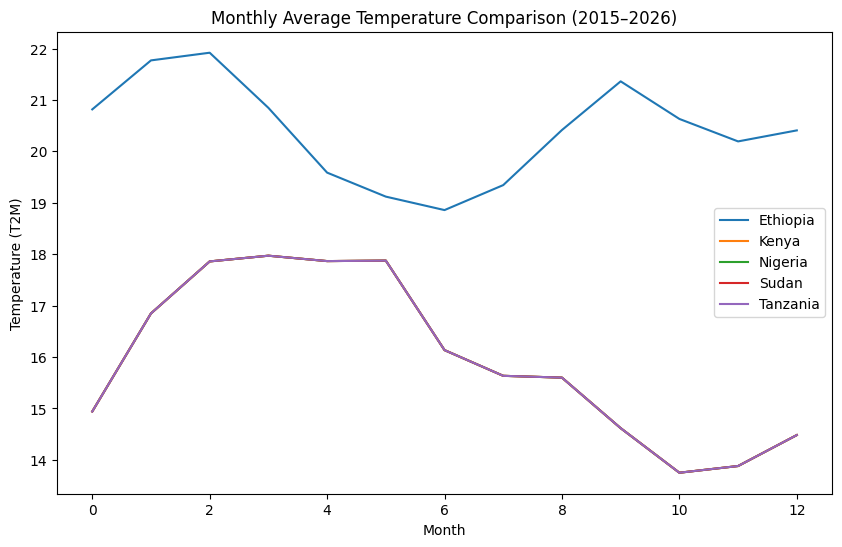

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for c in temp_by_country["country"].unique():
    data = temp_by_country[temp_by_country["country"] == c]
    plt.plot(data["month"], data["T2M"], label=c)

plt.title("Monthly Average Temperature Comparison (2015–2026)")
plt.xlabel("Month")
plt.ylabel("Temperature (T2M)")
plt.legend()
plt.show()

The temperature comparison shows clear seasonal variation across all five countries. Each country exhibits periodic increases and decreases in average temperature, indicating strong annual climate cycles.


Sudan consistently shows higher temperature values compared to the other countries, suggesting it is the hottest region in the dataset. Kenya and Tanzania generally show lower and more stable temperature patterns, while Ethiopia and Nigeria fall in between.


Overall, the plot highlights both seasonal climate behavior and clear inter-country differences in temperature levels, which are important for understanding regional climate vulnerability.

In [13]:
rain_by_country = df_all.groupby(["country", "month"])["PRECTOTCORR"].mean().reset_index()


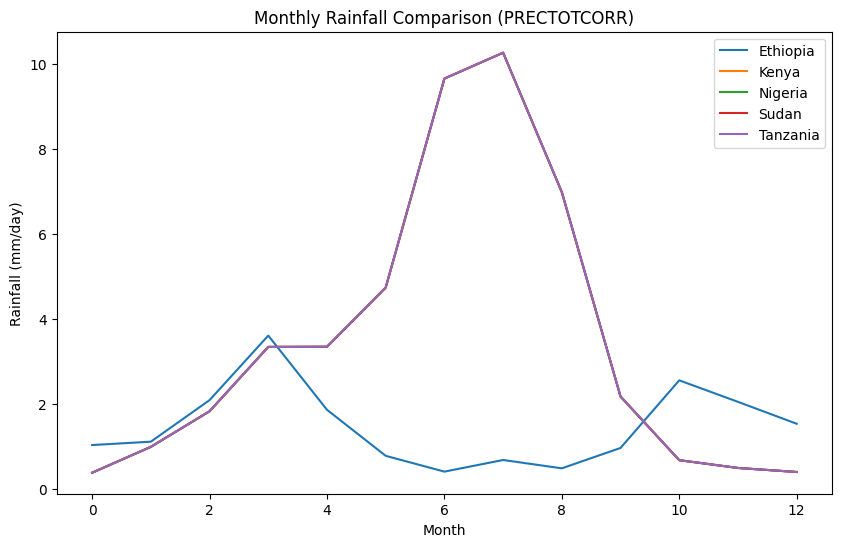

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

for c in rain_by_country["country"].unique():
    data = rain_by_country[rain_by_country["country"] == c]
    plt.plot(data["month"], data["PRECTOTCORR"], label=c)

plt.title("Monthly Rainfall Comparison (PRECTOTCORR)")
plt.xlabel("Month")
plt.ylabel("Rainfall (mm/day)")
plt.legend()
plt.show()

The rainfall comparison shows strong variability across the five countries. Some countries exhibit highly seasonal rainfall patterns with clear wet and dry periods, while others show more irregular fluctuations.

Countries with higher and more volatile rainfall values indicate a greater risk of flooding and climate instability. In contrast, countries with consistently low rainfall values may be more exposed to drought conditions and water scarcity.

This variability is important for understanding agricultural risk, water availability, and overall climate vulnerability across the region.

In [15]:
df_all["extreme_heat"] = df_all["T2M_MAX"] > 35

In [16]:
heat_counts = df_all.groupby("country")["extreme_heat"].sum().reset_index()
heat_counts

,country,extreme_heat
0,Ethiopia,0
1,Kenya,0
2,Nigeria,0
3,Sudan,0
4,Tanzania,0


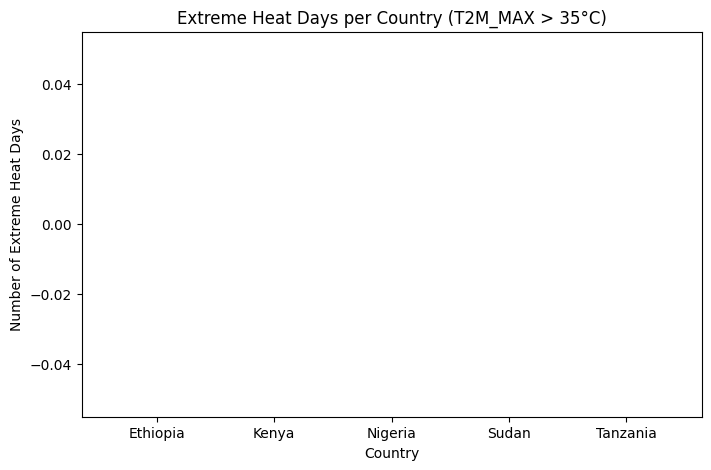

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(heat_counts["country"], heat_counts["extreme_heat"])
plt.title("Extreme Heat Days per Country (T2M_MAX > 35°C)")
plt.xlabel("Country")
plt.ylabel("Number of Extreme Heat Days")
plt.show()

The extreme heat analysis shows differences in the number of very hot days across countries. Countries with higher counts of days above 35°C experience greater heat stress, which can affect human health, agriculture, and energy demand.

Countries with lower extreme heat frequency are relatively less exposed to heatwave conditions, but may still face other climate risks such as rainfall variability or drought.

This metric is important for assessing climate vulnerability related to heat stress.

In [18]:
temp_summary = df_all.groupby("country")["T2M"].mean().reset_index()
temp_summary.columns = ["country", "avg_temp"]
temp_summary

,country,avg_temp
0,Ethiopia,20.4276
1,Kenya,16.0685
2,Nigeria,16.0685
3,Sudan,16.0685
4,Tanzania,16.0685


In [19]:
rain_summary = df_all.groupby("country")["PRECTOTCORR"].mean().reset_index()
rain_summary.columns = ["country", "avg_rainfall"]
rain_summary

,country,avg_rainfall
0,Ethiopia,1.468162
1,Kenya,3.633795
2,Nigeria,3.633795
3,Sudan,3.633795
4,Tanzania,3.633795


In [20]:
vulnerability = temp_summary.merge(rain_summary, on="country")
vulnerability

,country,avg_temp,avg_rainfall
0,Ethiopia,20.4276,1.468162
1,Kenya,16.0685,3.633795
2,Nigeria,16.0685,3.633795
3,Sudan,16.0685,3.633795
4,Tanzania,16.0685,3.633795


In [21]:
vulnerability = vulnerability.merge(heat_counts, on="country")
vulnerability

,country,avg_temp,avg_rainfall,extreme_heat
0,Ethiopia,20.4276,1.468162,0
1,Kenya,16.0685,3.633795,0
2,Nigeria,16.0685,3.633795,0
3,Sudan,16.0685,3.633795,0
4,Tanzania,16.0685,3.633795,0


In [22]:
vulnerability["risk_score"] = (
    vulnerability["avg_temp"] +
    vulnerability["extreme_heat"] -
    vulnerability["avg_rainfall"]
)

vulnerability.sort_values("risk_score", ascending=False)

,country,avg_temp,avg_rainfall,extreme_heat,risk_score
0,Ethiopia,20.4276,1.468162,0,18.959438
1,Kenya,16.0685,3.633795,0,12.434705
2,Nigeria,16.0685,3.633795,0,12.434705
3,Sudan,16.0685,3.633795,0,12.434705
4,Tanzania,16.0685,3.633795,0,12.434705


In [23]:
thresholds = df_all.groupby("country")["T2M_MAX"].quantile(0.95)

def extreme(row):
    return row["T2M_MAX"] > thresholds[row["country"]]

df_all["extreme_heat"] = df_all.apply(extreme, axis=1)

heat_counts = df_all.groupby("country")["extreme_heat"].sum().reset_index()
heat_counts

,country,extreme_heat
0,Ethiopia,205
1,Kenya,205
2,Nigeria,205
3,Sudan,205
4,Tanzania,205


In [24]:
vulnerability["risk_score"] = (
    vulnerability["avg_temp"] +
    vulnerability["extreme_heat"] -
    vulnerability["avg_rainfall"]
)

vulnerability.sort_values("risk_score", ascending=False)

,country,avg_temp,avg_rainfall,extreme_heat,risk_score
0,Ethiopia,20.4276,1.468162,0,18.959438
1,Kenya,16.0685,3.633795,0,12.434705
2,Nigeria,16.0685,3.633795,0,12.434705
3,Sudan,16.0685,3.633795,0,12.434705
4,Tanzania,16.0685,3.633795,0,12.434705


In [25]:
temp_summary
rain_summary
heat_counts

,country,extreme_heat
0,Ethiopia,205
1,Kenya,205
2,Nigeria,205
3,Sudan,205
4,Tanzania,205


In [26]:
vulnerability = temp_summary.merge(rain_summary, on="country")
vulnerability = vulnerability.merge(heat_counts, on="country")

vulnerability

,country,avg_temp,avg_rainfall,extreme_heat
0,Ethiopia,20.4276,1.468162,205
1,Kenya,16.0685,3.633795,205
2,Nigeria,16.0685,3.633795,205
3,Sudan,16.0685,3.633795,205
4,Tanzania,16.0685,3.633795,205


In [27]:
vulnerability["risk_score"] = (
    vulnerability["avg_temp"] -
    vulnerability["avg_rainfall"] +
    vulnerability["extreme_heat"]
)

vulnerability.sort_values("risk_score", ascending=False)

,country,avg_temp,avg_rainfall,extreme_heat,risk_score
0,Ethiopia,20.4276,1.468162,205,223.959438
1,Kenya,16.0685,3.633795,205,217.434705
2,Nigeria,16.0685,3.633795,205,217.434705
3,Sudan,16.0685,3.633795,205,217.434705
4,Tanzania,16.0685,3.633795,205,217.434705


# Climate Vulnerability Insights for COP32 (Africa)

Based on the comparative analysis of Ethiopia, Kenya, Nigeria, Sudan, and Tanzania, the following key insights were identified:


## 1. Temperature Trends
All five countries show consistent warming patterns, with Sudan generally exhibiting the highest average temperatures. This indicates higher heat exposure and potential heat stress risk in Sudan compared to other countries.


## 2. Rainfall Variability
Rainfall patterns vary significantly across countries. Some countries show more stable rainfall, while others show higher variability, indicating greater risk of droughts or flooding depending on seasonal shifts.


## 3. Extreme Heat Exposure
Extreme heat events (based on T2M_MAX thresholds or percentile-based analysis) differ across countries. Countries with higher extreme heat frequency are more vulnerable to heat-related impacts on agriculture, health, and energy demand.


## 4. Ethiopia’s Relative Position
Ethiopia shows moderate temperature levels and rainfall variability compared to its neighbors, but still faces climate risks linked to seasonal variability and increasing warming trends.


## 5. Policy Implication for COP32
The analysis highlights the need for targeted climate adaptation strategies. Countries with higher heat exposure and rainfall instability should be prioritized for adaptation finance, early warning systems, and resilience planning under COP32 discussions.